# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [3]:
counts = y.value_counts()
counts.index = counts.index.map({0: "non diabétique", 1: "diabétique"})

print(counts)

class
non diabétique    500
diabétique        268
Name: count, dtype: int64


## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,random_state=66)

arbre.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train: 0.783
Accuracy test: 0.714
                precision    recall  f1-score   support

non_diabetique       0.75      0.84      0.79       125
    diabetique       0.62      0.48      0.54        67

      accuracy                           0.71       192
     macro avg       0.68      0.66      0.67       192
  weighted avg       0.70      0.71      0.70       192



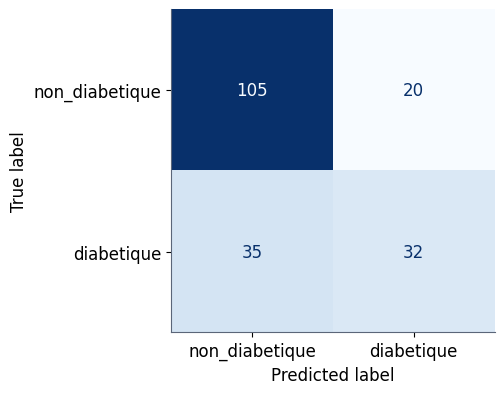

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


print(f"Accuracy train: {arbre.score(X_train,y_train):.3f}")
print(f"Accuracy test: {arbre.score(X_test,y_test):.3f}")

y_pred = arbre.predict(X_test)

print(classification_report(y_test, y_pred,target_names=CLASSES))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

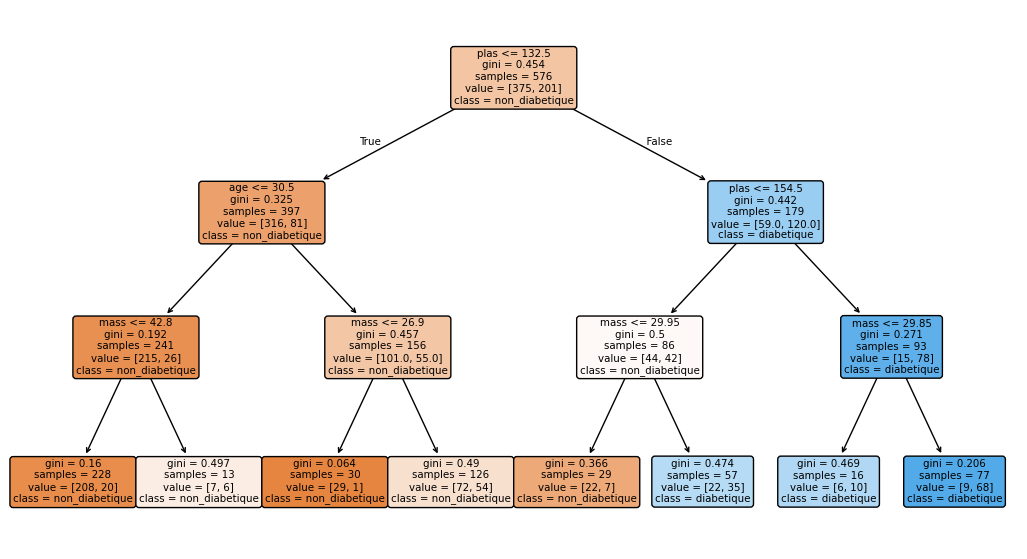

In [8]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(arbre, feature_names=X.columns, class_names=CLASSES, filled=True, rounded=True)

plt.show()

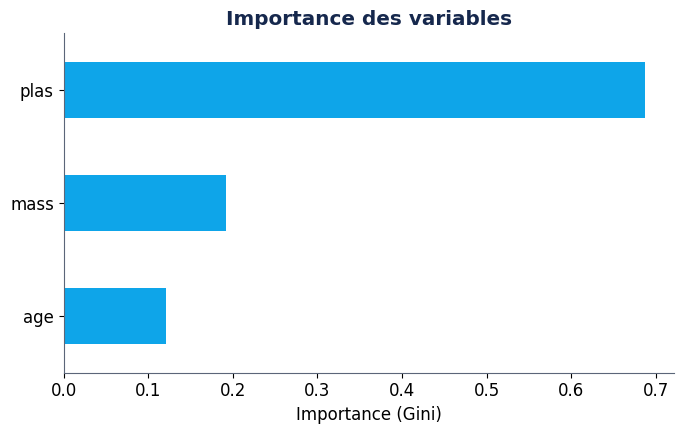

In [9]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
imp.plot(kind="barh", color=ACCENT)
plt.title("Importance des variables")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [10]:
ech = X_test.head(5)
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:,1]

df_res = pd.DataFrame({
    "reel"      : y_test.head(5).map({0: "non_diabetique", 1: "diabetique"}).values,
    "predit"    : [CLASSES[p] for p in pred],
    "proba_diab": proba.round(3),
})
print(df_res)

             reel          predit  proba_diab
0      diabetique  non_diabetique       0.429
1  non_diabetique  non_diabetique       0.088
2  non_diabetique  non_diabetique       0.088
3      diabetique      diabetique       0.614
4      diabetique      diabetique       0.883


In [12]:
for depth in [2,3,6,None]:
    arbreTest = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=10,random_state=66)
    arbreTest.fit(X_train,y_train)
    print(f"max_depth={str(depth):4s}  train={arbreTest.score(X_train, y_train):.3f}  test={arbreTest.score(X_test, y_test):.3f}")


max_depth=2     train=0.760  test=0.708
max_depth=3     train=0.783  test=0.714
max_depth=6     train=0.830  test=0.755
max_depth=None  train=0.835  test=0.766


## Comparaison de modèles et stockage


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
import pickle

modeles = {
    "DecisionTree" : arbre,   # déjà entraîné
    "RandomForest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost"      : XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"),
}

resultats = {}
for nom, m in modeles.items():
    if nom != "DecisionTree":
        m.fit(X_train, y_train)
    y_pred_m = m.predict(X_test)
    resultats[nom] = {
        "accuracy" : m.score(X_test, y_test),
        "recall_diabetique" : recall_score(y_test, y_pred_m),
    }

df_resultats = pd.DataFrame(resultats).T
print(df_resultats)


## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?